<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Meteorological-inputs" data-toc-modified-id="Meteorological-inputs-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Meteorological inputs</a></span></li><li><span><a href="#A-better-way-to-plot-the-data" data-toc-modified-id="A-better-way-to-plot-the-data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>A better way to plot the data</a></span></li></ul></div>

<div style="float:right">
    <table>
    <tr>
        <td> <img src="figs/kcl_logo.png" alt="Drawing" style="width:54px;height:40px;"/> 
        <td> <img src="figs/nceo_logo.png" alt="Drawing" style="width:200px;height:40px;"/> 
        <td> <img src="figs/multiply_logo.png" alt="Drawing" style="width:40px;height:40px;"/>
    </tr>
    </table>
</div>

# Meteorological data and crops

**Author:** Jose Gómez-Dans (NCEO & KCL)  `jose.gomez-dans@kcl.ac.uk`


In [1]:
%load_ext autoreload
%autoreload 2


import datetime as dt
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

from meteo_funcs import *


Bad key keymap.all_axes in file matplotlibrc, line 398 ('keymap.all_axes : a                 # enable all axes')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution



## Meteorological inputs

Meteorology is a major factor in determining crop growth. Crop models require meteo inputs to calculate crop development (phenology), carbon assimilation (e.g. photosynthesis) and calculate any stresses (e.g. effect of drought). Accurate and timely sources of meteorological data are hard to come by. Recent developments in the operationalistation of reanalysis datasets (where a climate model is combined with the best observational record to produce an *analysis* of the state of the climate system) now routinely provide global fields of meteorological data. We note that this data is probably inaccurate at small scales, but it's availability means that we can run crop models anywhere.

For these examples, we'll be using the [ERA 5 Reanalysis product](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels?tab=overview) from the [Copernicus Climate Change Service](https://cds.climate.copernicus.eu/cdsapp#!/home) (note that a newer version over land, [ERA5-Land](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-land?tab=overview) has also been recently been made available).

The variables of interest for most crop models are:

* Downwelling radiance
* Minimum and maximum daily temperatures
* Vapour pressure
* Wind speed
* Precipitation

It is probably fair to say that estimates of things like precipitation and wind speed will be very local, and the global reanalysis data will look quite different to local *in situ* measurements. Likewise, radiance and temperatures can probably suffer from very local biases due to local orography. These observations suggest that the drivers of our crop model will be **in error** or have some degree of uncertainty associated to them, and this uncertainty will be carried on to the model output.

It also means that all crops within a grid cell will all share the same drivers. Assuming they all share information on crop variety and soils (or have soils parameterised again in error), it means that all crops within a meteo cell will have the same evolution, as the crop model only knows about parameters, meteo and soils! This is clearly very different to what we see in reality, where there is a very large variation of crop evolution and condition even within a single field.

Data assimilation techniques are one way to locally "correct" the crop growth model to track the actual situation that is happening in the field. By using a partial view of the crop (e.g. the LAI, or soil moisture, etc.), we can see whether the prediction from the crop model follows the observations (given their often substantial uncertainty), and then correct the model to track the observations.

Data for all of Africa from years 2010 until 2019 has been provided for you (it is possible to downnload it, but can take a while). Due to problems with the infrastructure, we are only able to provide you with meteorological data for a few points, which we have taken to be the centroid of each of Ghana's regions.


interactive(children=(Dropdown(description='Region:', index=2, options=('Ashanti', 'Brong_Ahafo', 'Central', '…

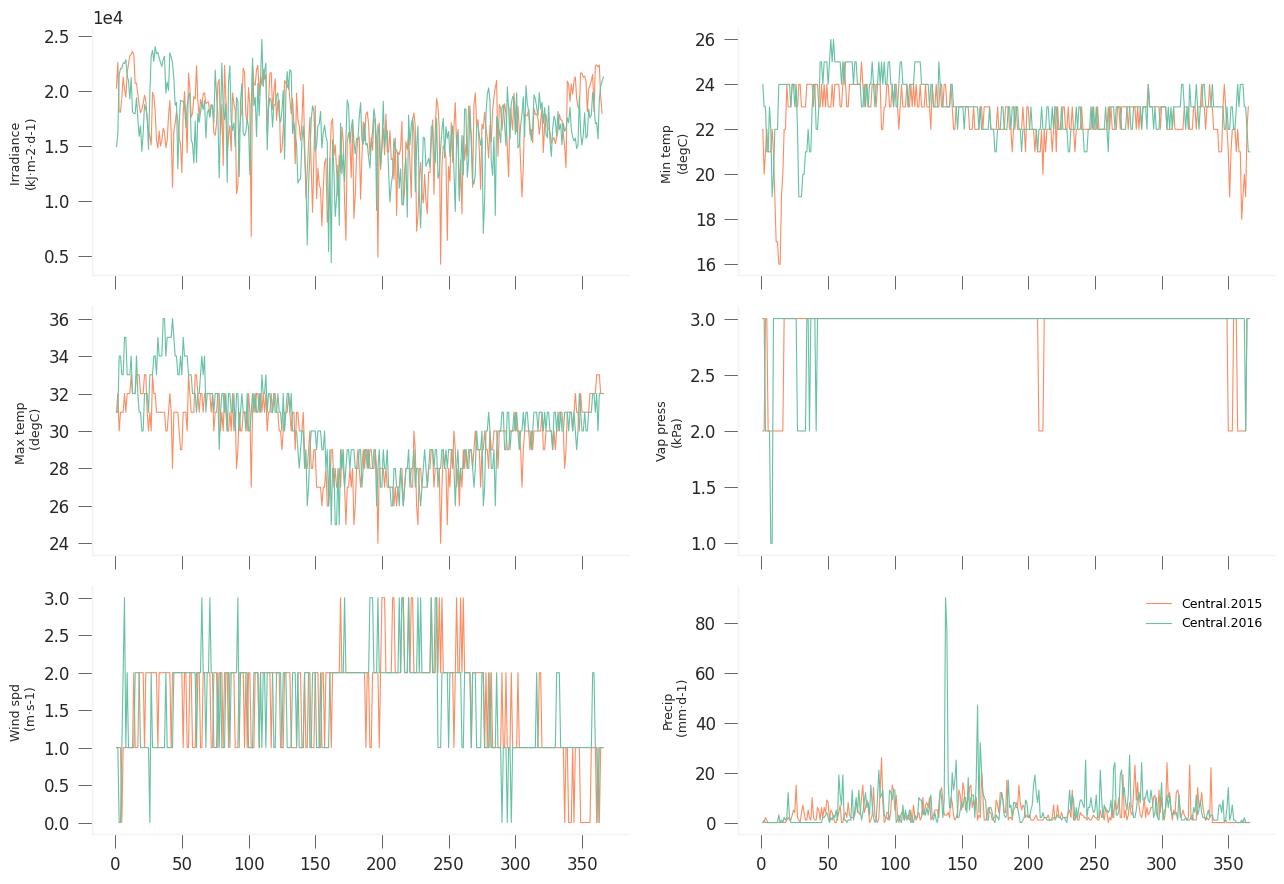

In [2]:
get_region_data();

The previous plots are hard to visualise. What's really *going on* there? We can clearly see a temperature seasonality, with cooler temperatures around days of the year 200 to 300. We can also see that the irradiance is very changing, and we can also see that wind speed and vapour pressure deficit are probably not very accurate estimates. Precipitation is also very changing, but it is hard to see any trends. 


## A better way to plot the data

We need to think of a better way to display the data. We can look up [a crop calendar](http://www.fao.org/agriculture/seed/cropcalendar/welcome.do) (or even direct understanding) to see the period where the crop is present. This is an oversimplification, but it's a starting point. We can then think of ways of aggregating the data. The following exercise allows you to plot variables using different starting and ending times.

interactive(children=(SelectionRangeSlider(description='Sowing & Harvest', index=(0, 364), layout=Layout(width…

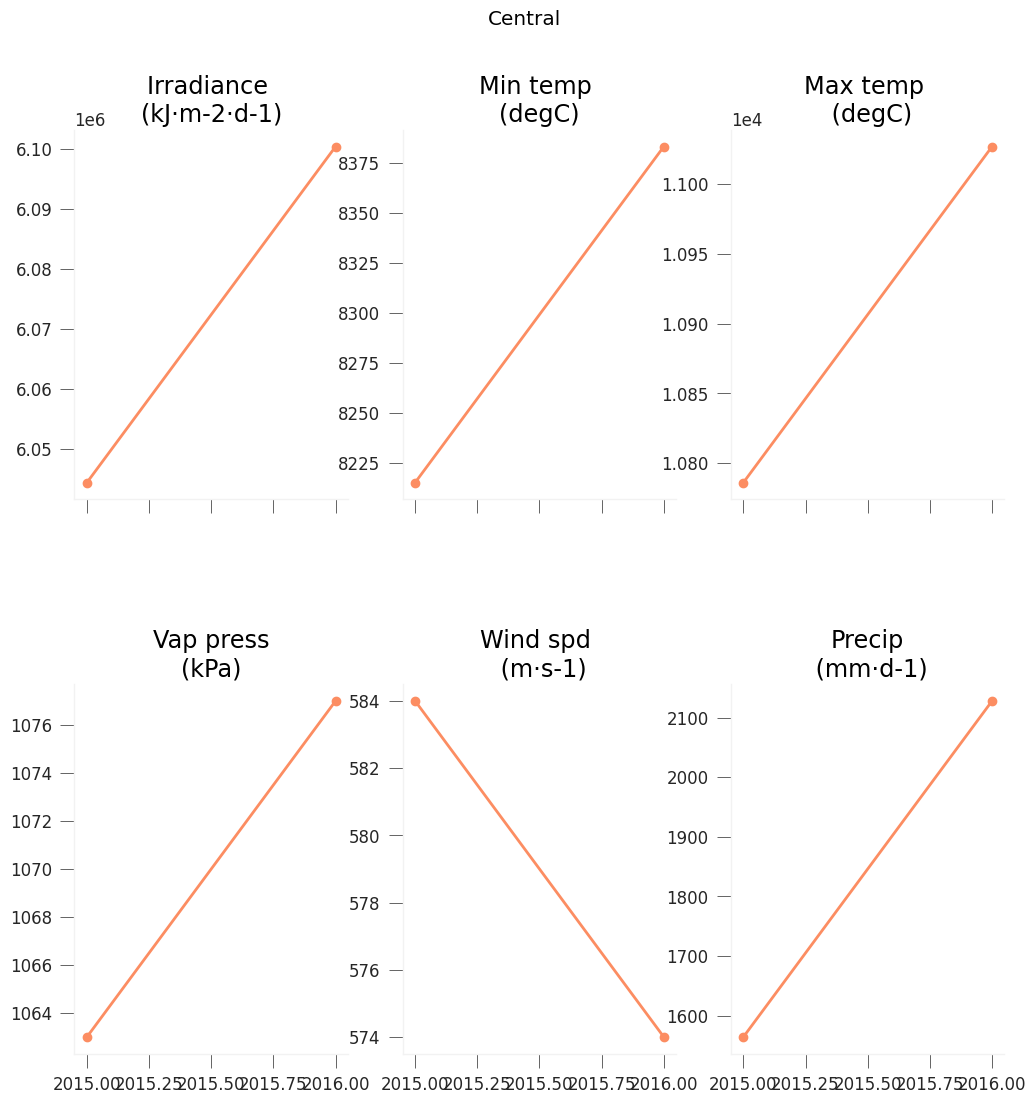

In [ ]:
aggregate_plots();

# Some observations

The above plots show that we can have a rough idea of crop condition based on meteorological data. However,

* Meteorological data is only available at a fairly sparse resolution.
* Reanalysis data should be compared with *in situ* measurements to understand its limitations, which are many and change from region to region and seasonally.
* Although seasonal forecasts are becoming more common, their skill may hamper sensible predictions.
* Weather is one of the many factors affecting crop growth. Other important factors are to do with soils, crop variety, farmer management decisions, pests, etc.

The last point is very important: meteorological data is important, but insufficient on its own to give us insights into crop development.

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons Licence" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.